In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


conn = sqlite3.connect('chinook.db')
cursor = conn.cursor()


cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

print(" Connection successful!")
print("Available tables in the database:")
for table in tables:
    print(f" - {table}")

 Connection successful!
Available tables in the database:
 - Album
 - Artist
 - Customer
 - Employee
 - Genre
 - Invoice
 - InvoiceLine
 - MediaType
 - Playlist
 - PlaylistTrack
 - Track


In [2]:

print("--- Track Table Preview ---")
display(pd.read_sql_query("SELECT * FROM Track LIMIT 3;", conn))

print("\n--- InvoiceLine Table Preview ---")
display(pd.read_sql_query("SELECT * FROM InvoiceLine LIMIT 3;", conn))

--- Track Table Preview ---


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99



--- InvoiceLine Table Preview ---


,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1


In [3]:
# SQL Query: Join Track and InvoiceLine, aggregate quantities
query_tracks = """
SELECT 
    t.Name AS TrackName, 
    a.Title AS AlbumTitle,
    SUM(il.Quantity) AS TotalUnitsSold
FROM Track t
JOIN InvoiceLine il ON t.TrackId = il.TrackId
JOIN Album a ON t.AlbumId = a.AlbumId
GROUP BY t.TrackId
ORDER BY TotalUnitsSold DESC, TrackName ASC
LIMIT 10;
"""

# Load into DataFrame
df_tracks = pd.read_sql_query(query_tracks, conn)

print(" TOP 10 BEST-SELLING TRACKS:")
df_tracks

 TOP 10 BEST-SELLING TRACKS:


,TrackName,AlbumTitle,TotalUnitsSold
0,A Cor Do Sol,Acústico MTV [Live],2
1,A Melhor Forma,Acústico,2
2,A Novidade (Live),Quanta Gente Veio Ver (Live),2
3,"Abraham, Martin And John",Seek And Shall Find: More Of The Best (1963-1981),2
4,Aces High,Powerslave,2
5,All Along The Watchtower,Rattle And Hum,2
6,Amor De Muito,Afrociberdelia,2
7,Ando Meio Desligado,Minha História,2
8,As Rosas Não Falam (Beth Carvalho),Vozes do MPB,2
9,Azul,Djavan Ao Vivo - Vol. 1,2


In [4]:

query_country = """
SELECT 
    BillingCountry AS Country, 
    ROUND(SUM(Total), 2) AS TotalRevenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC;
"""


df_country = pd.read_sql_query(query_country, conn)

print("GLOBAL REVENUE BY COUNTRY (Top 10):")
df_country.head(10)

GLOBAL REVENUE BY COUNTRY (Top 10):


,Country,TotalRevenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


In [5]:

query_sales = """
SELECT 
    e.FirstName || ' ' || e.LastName AS EmployeeName,
    e.Title AS JobTitle,
    ROUND(SUM(i.Total), 2) AS TotalSalesRevenue
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId
ORDER BY TotalSalesRevenue DESC;
"""

df_sales = pd.read_sql_query(query_sales, conn)

print("SALES TEAM PERFORMANCE LEADERBOARD:")
df_sales

SALES TEAM PERFORMANCE LEADERBOARD:


,EmployeeName,JobTitle,TotalSalesRevenue
0,Jane Peacock,Sales Support Agent,833.04
1,Margaret Park,Sales Support Agent,775.40
2,Steve Johnson,Sales Support Agent,720.16


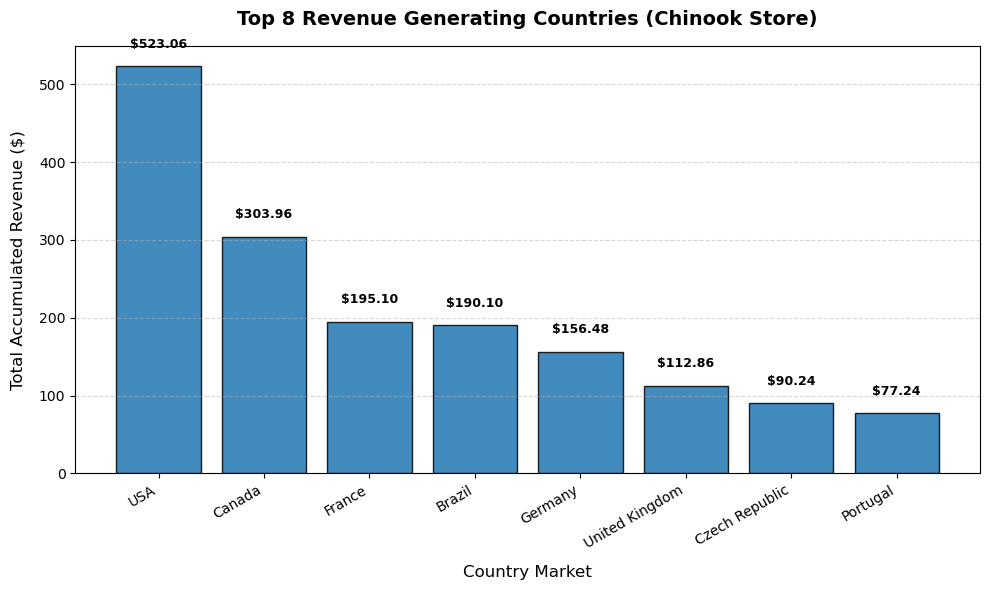

In [6]:

top_markets = df_country.head(8)


plt.figure(figsize=(10, 6))
bars = plt.bar(top_markets['Country'], top_markets['TotalRevenue'], color='#1f77b4', edgecolor='black', alpha=0.85)


plt.title('Top 8 Revenue Generating Countries (Chinook Store)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country Market', fontsize=12, labelpad=10)
plt.ylabel('Total Accumulated Revenue ($)', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 20, f"${yval:,.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()


plt.show()

In [7]:
conn.close()
print(" Database connection securely closed. Safe to close notebook environment.")

 Database connection securely closed. Safe to close notebook environment.
